**Name:**

**Student ID:**

Transform this notebook into a technical report on experiments using a **VAE (Variational Autoencoder)** architecture.

* Add comments to the different code blocks, explaining the purpose of each one.
* Explain how the **latent space** is constructed. Show different results for various configurations.
* Change the model's training parameters.
* Propose ways to evaluate the quality of the generated samples.

### Attr2Font

* **Github:** [https://github.com/hologerry/Attr2Font](https://github.com/hologerry/Attr2Font)
* **Dataset:** [https://drive.google.com/file/d/1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_/view](https://drive.google.com/file/d/1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_/view)

### Importing Libs

In [18]:
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets,transforms
from torchvision.utils import save_image
from tqdm.notebook import tqdm
import os
import shutil
import random
random.seed(5)
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format='svg'
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np


### Google Drive

In [19]:
## Connects with google if necessary
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

### Data

In [20]:
import os
import subprocess
import shutil

# Check if the zip and folder do not exist
if not os.path.exists("explor_all.zip") and not os.path.exists("explor_all"):
    # Download the dataset
    subprocess.run(
        ["gdown", "--id", "1TTqAklfsAp6KOPxCVl2jktH8kN4lEmI_"], check=True
    )
    subprocess.run(["unzip", "explor_all.zip"], check=True)

    # Make sure needed dirs exist
    os.makedirs("data", exist_ok=True)
    os.makedirs("results", exist_ok=True)
    os.makedirs("models", exist_ok=True)

    # Move the folder
    shutil.move("explor_all/image", "data/Fonts")

    print("✅ Dataset downloaded, extracted, and moved successfully!")
else:
    print("⚠️ Skipped: either zip file or folder already exists.")

⚠️ Skipped: either zip file or folder already exists.


In [21]:
epochs=5
batch_size=128
torch.manual_seed(17)

In [22]:
def show_img(img):
    img = img.permute(1, 2, 0)
    if img.shape[2]==1:
        img = img.view(img.shape[0], img.shape[1])
    plt.title(f'Image has size {img.cpu().numpy().shape}')
    plt.imshow(img,cmap='gray')
    plt.axis('off')
    plt.show()

In [23]:
path='data/Fonts'
train_path = 'data/trainFonts'
val_path = 'data/valFonts'

In [24]:
transforms_all = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=50),
    transforms.ToTensor()
])

dummy_batch = torch.utils.data.DataLoader(
    datasets.ImageFolder(path,transform=transforms.ToTensor()),
    batch_size=1, shuffle=True
)

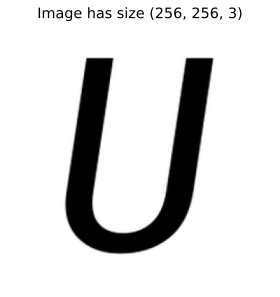

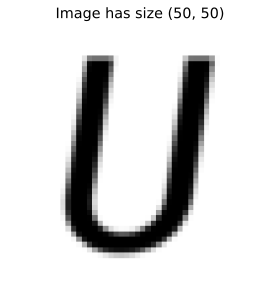

In [25]:
for batch in dummy_batch:
  original_image=batch[0][0]
  show_img(original_image)
  show_img(transforms_all(transforms.ToPILImage()(original_image)))
  break

### Splitting Data into Training and Validation Sets

In [26]:
folders=os.listdir(path)
print(len(folders))

# shutil.rmtree('/content/drive/MyDrive/Corpora/trainFonts')
# shutil.rmtree('/content/drive/MyDrive/Corpora/valFonts')

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

# Podemos limitar em num_folders a quantidade total de pasta que iremos trabalhar, no total temos 1116.
num_folders = 134
count_folders = 1
for folder in tqdm(folders):
    if count_folders <= num_folders:
      os.makedirs(f'{train_path}/{folder}', exist_ok=True)
      os.makedirs(f'{val_path}/{folder}', exist_ok=True)
      images = os.listdir(f'{path}/{folder}')
      random.shuffle(images)
      for image in images[:20]:
        shutil.copy(f'{path}/{folder}/{image}',
                  f'{val_path}/{folder}/{image}')
      for image in images[20:]:
        shutil.copy(f'{path}/{folder}/{image}',
                  f'{train_path}/{folder}/{image}')
    count_folders += 1

1116


  0%|          | 0/1116 [00:00<?, ?it/s]

In [27]:
print(len(os.listdir(train_path)))
print(len(os.listdir(val_path)))

134
134


### Building dataloader

In [28]:
transforms_set = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=50),
    transforms.ToTensor()
])

train_loader=torch.utils.data.DataLoader(
    datasets.ImageFolder(f'{train_path}',transform=transforms_set),
    batch_size=batch_size, shuffle=True
)

val_loader=torch.utils.data.DataLoader(
    datasets.ImageFolder(f'{val_path}',transform=transforms_set),
    batch_size=batch_size, shuffle=True
)

### VAE implementation

In [29]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()


        z = 32 # Latent space dimensions

        #ENCODER
        self.fc1 = nn.Linear(50*50,1000) # Include comments
        self.fc21 = nn.Linear(1000,z)   # Include comments
        self.fc22 = nn.Linear(1000,z)   # Include comments

        #DECODER
        self.fc3 = nn.Linear(z,1000)
        self.fc4 = nn.Linear(1000,50*50)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):

        # don't forget forward pass re-index

        mu, logvar = self.encode(x.view(-1, 50*50))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Loss Function Implementation

In [30]:
def loss_function(recon_x, x, mu, logvar):

    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 50*50), reduction='sum')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

### Building the Model

In [31]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=VAE().to(device)
print('Device: ',device)
model=VAE().to(device)
optimizer=optim.Adam(model.parameters(),lr=1e-3)

Device:  cuda


### Loops de Treinamento e Avaliação

In [32]:
def evaluate(evaluate_data=val_loader):


    val_loss = 0
    with torch.no_grad():
        for i, (data, _) in enumerate(evaluate_data):

            data=data.to(device)
            recon_batch,mu,logvar=model(data)
            val_loss += loss_function(recon_batch,data,mu,logvar).item()


            if i == 0:
                n = min(data.size(0), 16)
                comparison = torch.cat([data[:n],
                                        recon_batch.view(batch_size, 1, 50, 50)[:n]])
                save_image(comparison.cpu(),
                           'results/reconstruction_' + str(epoch) + '.png', nrow=n)

    val_loss /= len(evaluate_data.dataset)
    return val_loss


def sample_latent_space(epoch):
    with torch.no_grad():

        # how to sample from our latent space
        sample=torch.randn(64,32).to(device)
        sample=model.decode(sample).cpu()

        save_image(sample.view(64, 1, 50, 50),
                   'results/sample_' + str(epoch) + '.png')

In [33]:
def train(epoch):

    model.train()
    train_loss = 0

    progress_bar = tqdm(train_loader, desc='Epoch {:03d}'.format(epoch), leave=False, disable=False)
    for data, _ in progress_bar:

        data=data.to(device)
        optimizer.zero_grad()
        recon_batch,mu,logvar=model(data)

        loss=loss_function(recon_batch,data,mu,logvar)
        loss.backward()
        train_loss+=loss.item()
        optimizer.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item() / len(data))})

    average_train_loss = train_loss / len(train_loader.dataset)
    tqdm.write('Training set loss (average, epoch {:03d}): {:.3f}'.format(epoch, average_train_loss))
    val_loss = evaluate(val_loader)
    tqdm.write('\t\t\t\t====> Validation set loss: {:.3f}'.format(val_loss))

    train_losses.append(average_train_loss)
    val_losses.append(val_loss)

    if epoch%50==0:
        torch.save(model.state_dict(), f'models/epoch_{epoch}.model')

### Training

In [34]:
epochs = 300

train_losses,val_losses=[],[]

for epoch in range(1,epochs+1):
  train(epoch)
  sample_latent_space(epoch)

  np.savetxt('models/training_losses.txt', np.array(train_losses), delimiter='\n')
  np.savetxt('models/validation_losses.txt', np.array(val_losses), delimiter='\n')


Epoch 001:   0%|          | 0/44 [00:00<?, ?it/s]

Training set loss (average, epoch 001): 767.030
				====> Validation set loss: 607.366


Epoch 002:   0%|          | 0/44 [00:00<?, ?it/s]

Training set loss (average, epoch 002): 551.338
				====> Validation set loss: 524.641


Epoch 003:   0%|          | 0/44 [00:00<?, ?it/s]

...

Training set loss (average, epoch 152): 222.836
				====> Validation set loss: 265.780


Epoch 153:   0%|          | 0/44 [00:00<?, ?it/s]

Training set loss (average, epoch 153): 222.029
				====> Validation set loss: 266.152


Epoch 154:   0%|          | 0/44 [00:00<?, ?it/s]

KeyboardInterrupt: 

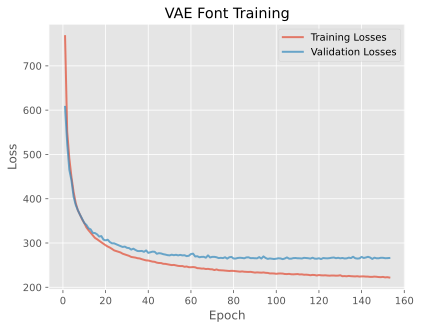

In [37]:
train_losses=np.loadtxt('models/training_losses.txt')
val_losses=np.loadtxt('models/validation_losses.txt')
plt.plot(
    range(1,len(train_losses)+1),
    train_losses,
    label='Training Losses',
    linewidth=2,
    alpha=0.7
)
plt.plot(
    range(1,len(val_losses)+1),
    val_losses,
    label='Validation Losses',
    linewidth=2,
    alpha=0.7
)

plt.title('VAE Font Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
pass

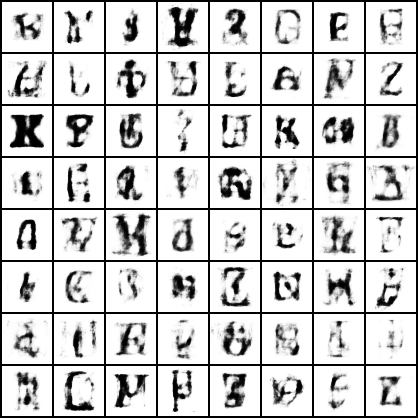

In [42]:
model.load_state_dict(
    torch.load('models/epoch_150.model',
               map_location=torch.device('cpu')))

sample_latent_space('a')

from PIL import Image

image = Image.open("results/sample_a.png")
image

In [39]:
# zip files to download
!zip -r results.zip results
!zip -r models.zip models

  adding: results/ (stored 0%)
  adding: results/sample_59.png (deflated 3%)
  adding: results/reconstruction_48.png (deflated 4%)
  adding: results/sample_53.png (deflated 2%)
  adding: results/sample_145.png (deflated 3%)
  adding: results/sample_27.png (deflated 2%)
  adding: results/sample_135.png (deflated 3%)
  adding: results/reconstruction_67.png (deflated 4%)
  adding: results/sample_66.png (deflated 3%)
  adding: results/reconstruction_78.png (deflated 4%)
  adding: results/sample_83.png (deflated 3%)
  adding: results/sample_42.png (deflated 2%)
  adding: results/sample_125.png (deflated 3%)
  adding: results/reconstruction_124.png (deflated 4%)
  adding: results/reconstruction_137.png (deflated 4%)
  adding: results/reconstruction_27.png (deflated 3%)
  adding: results/reconstruction_26.png (deflated 3%)
  adding: results/sample_52.png (deflated 2%)
  adding: results/reconstruction_111.png (deflated 4%)
  adding: results/reconstruction_73.png (deflated 4%)
  adding: results

In [ ]:
# zip files to local folder
from google.colab import files
files.download('models.zip')
files.download('results.zip')